## For n = 20 for each data set:
### a. Run the brute force algorithm for the Vertex Cover problem. Record  the size of the computed vertex cover and the running time.
### b. Run the greedy approximation algorithm for the Vertex Cover problem. Record  the size of the computed vertex cover and the running time
### c. Compute the Approximation factor of greedy by comparing the results with those of brute force

In [2]:
import networkx as nx        # For creating and analyzing graphs/networks
import matplotlib.pyplot as plt  # For plotting and visualizing graphs
import time                  # For measuring execution time or adding delays
import pandas as pd          # For handling tabular data (DataFrames)
import random                # For generating random numbers and choices
import numpy as np           # For numerical operations and arrays
import itertools             # For efficient looping and combinatorial tools

In [3]:
def read_graphs(nodes, edges):
    """
    Parameters : 
    nodes : int
        Number of nodes in each graph (used for naming files).
    edges : numpy array
        Sequence of edge counts.
        
    Returns :
    graphs_list : list
        A list of NetworkX graphs read from the files.
    """
    graphs_list = []
    n = nodes
    for m in edges:
        filename = f"n={n}_m={m}.txt"
        G = nx.read_edgelist(filename)
        graphs_list.append(G)
    return graphs_list


In [4]:
def vertex_cover_brute_force(G):
    """
    Brute-force algorithm to find a vertex cover of graph G.
    
    - Tries all possible subsets of nodes.
    - Returns the first subset that covers all edges.
    
    Parameters :
    G : networkx.Graph (Input graph)
    
    Returns :
    set
        A set of nodes that forms a vertex cover.

    itertools.combinations(nodes, r) has been generated from chatgpt
    """
    n = len(G.nodes())
    nodes = list(G.nodes())

    for r in range(n + 1):
        for subset in itertools.combinations(nodes, r):
            is_cover = True
            for u, v in G.edges():
                if not (u in subset or v in subset):
                    is_cover = False
                    break
            if is_cover:
                return set(subset)
    return set()


In [5]:
def vertex_cover_2approx(G):
    """
    2-approximation algorithm for Vertex Cover.
    Picks a random edge, adds both endpoints to the cover,
    removes all edges incident on them, and repeats.
    
    Returns
    -------
    C : set
        Approximate vertex cover.
    M : set
        Matching used to build the cover.
    """
    C = set()  # vertex cover
    M = set()  # matching
    edges = set(G.edges())

    while edges:
        (u, v) = random.choice(list(edges))  # pick a random edge
        C.add(u)
        C.add(v)
        M.add((u, v))
        # remove edges covered by u or v
        edges = {e for e in edges if u not in e and v not in e}

    return C, M


In [6]:
def generate_vertex_covers(method):
    """
    Generate vertex covers for graphs and record results.

    - Reads graphs with n=20 and varying m values.
    - Computes vertex cover using either:
        method=0 → brute force
        method=1 → 2-approximation
    - Colors nodes (red = in vertex cover, green = not in cover).
    - Saves each graph as a PNG with cover size and runtime info.

    Parameters :
    method : int
        0 for brute force, 1 for 2-approximation.

    Returns :
    results : list of dict
        Each dict contains:
        {
            "n": number of nodes,
            "m": number of edges,
            "vertex_cover_size": size of cover found,
            "time_(in seconds)": runtime
        }
    """
    results = []
    n = 20
    m = np.arange(20, 200, 10)
    graphs = read_graphs(n, m)
    
    for i, graph in enumerate(graphs, start=1): 
        if method == 0:
            start_time = time.perf_counter()
            vc = vertex_cover_brute_force(graph)
            end_time = time.perf_counter()
        elif method == 1:
            start_time = time.perf_counter()
            vc, max_match = vertex_cover_2approx(graph)
            end_time = time.perf_counter()
            
        node_colors = ['red' if node in vc else 'green' for node in graph.nodes()]
        
        plt.figure(figsize=(6, 6))
        pos = nx.circular_layout(graph)
        nx.draw(graph, pos, with_labels=True, node_color=node_colors, edge_color="blue")

        if method == 1:
            # Highlight matching edges in yellow
            nx.draw_networkx_edges(graph, pos, edgelist=max_match, edge_color="yellow", width=2.5)

        # Add graph info (n, m, cover size, runtime) as text
        # used plt.text from chatgpt to ensure saving values of n,m and size of vertex cover an the time taken
        plt.text(0.01, 0.02,
                 f"n={n}, m={m[i-1]}, Vertex Cover Size={len(vc)}, time (in seconds)={(end_time - start_time):.6f}",
                 transform=plt.gca().transAxes, fontsize=10, color="black",
                 bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    
        # Save visualization
        if method == 0:
            plt.savefig(f"B_F_n=20,m={m[i-1]}.png")
        elif method == 1:
            plt.savefig(f"2_Approx_n=20,m={m[i-1]}.png")
            
        # Store results
        results.append({
            "n": 20,
            "m": m[i-1],
            "vertex_cover_size": len(vc),
            "time_(in seconds)": end_time - start_time
        })
    return results

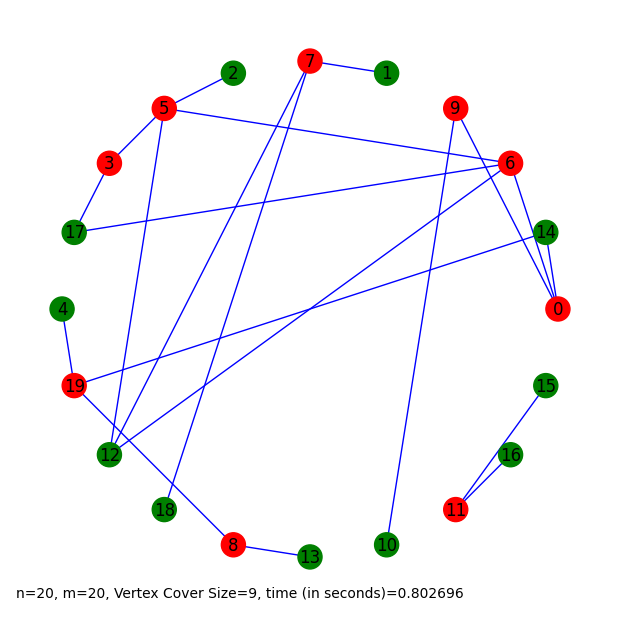

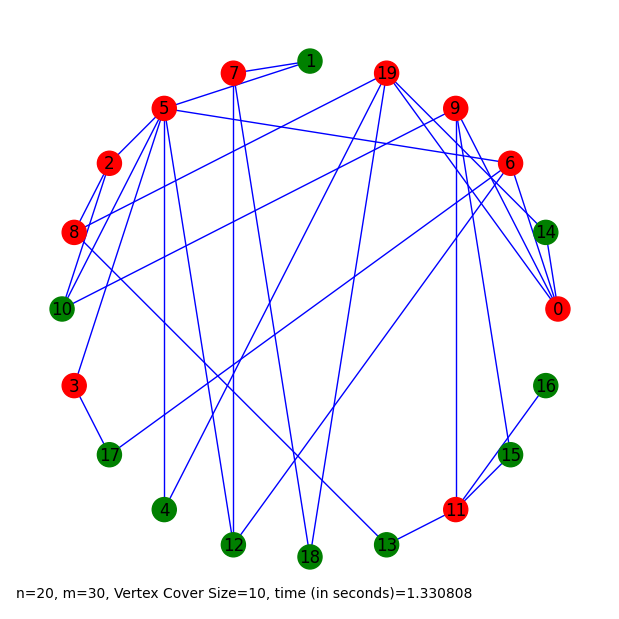

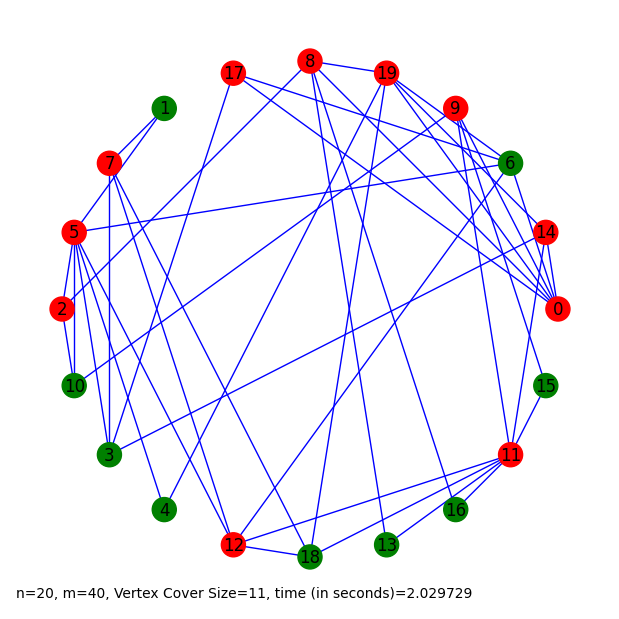

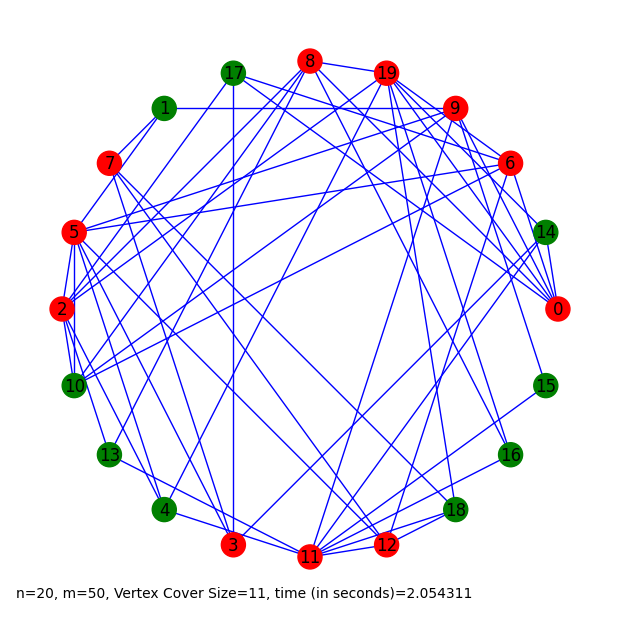

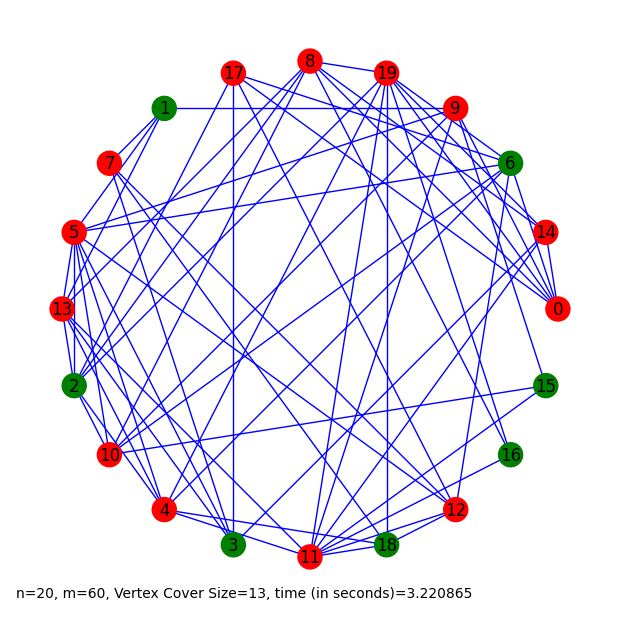

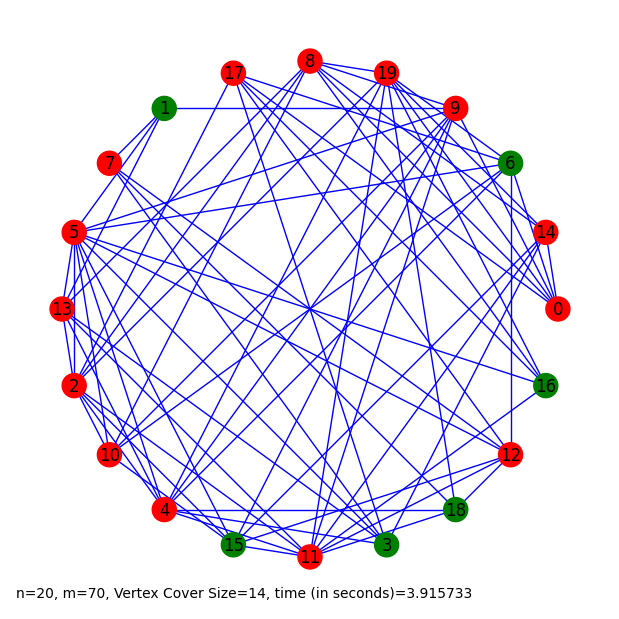

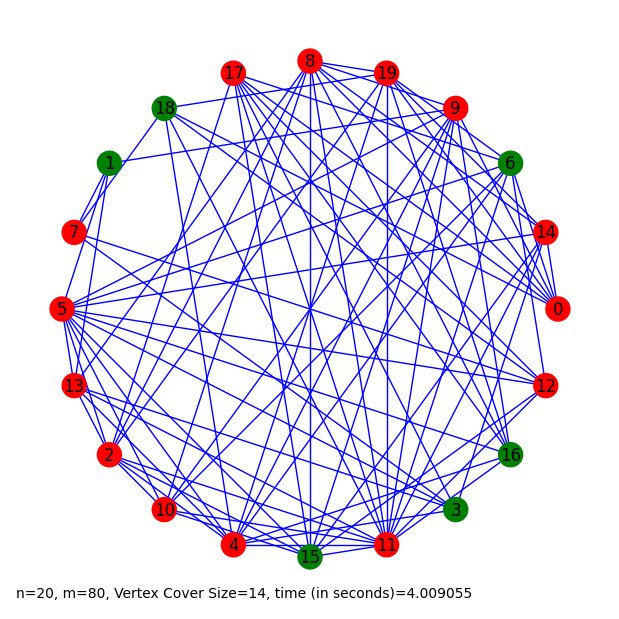

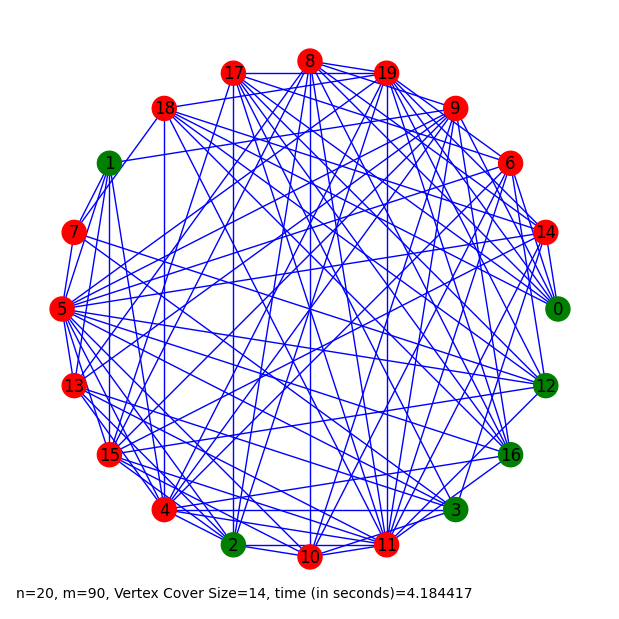

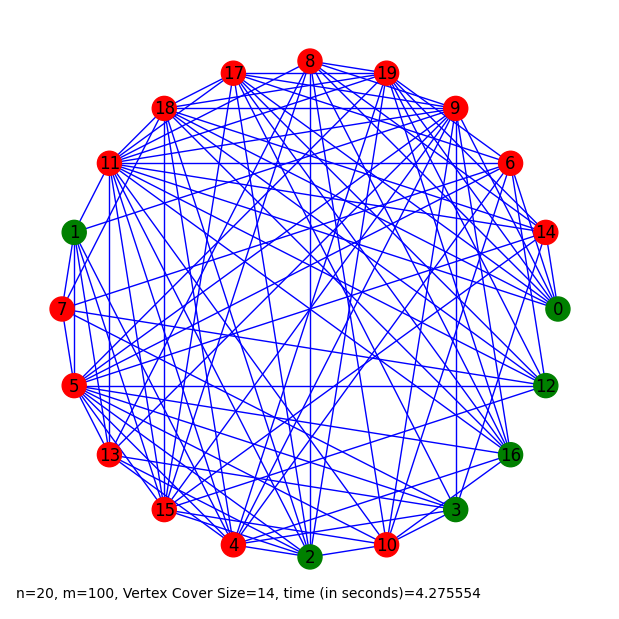

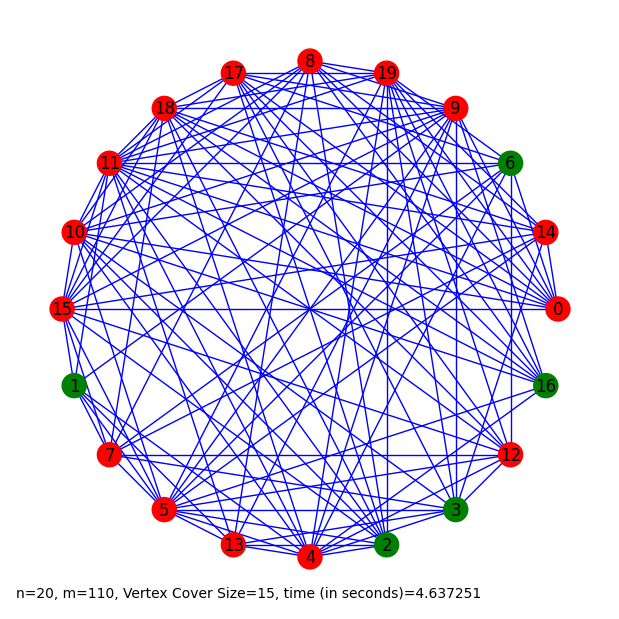

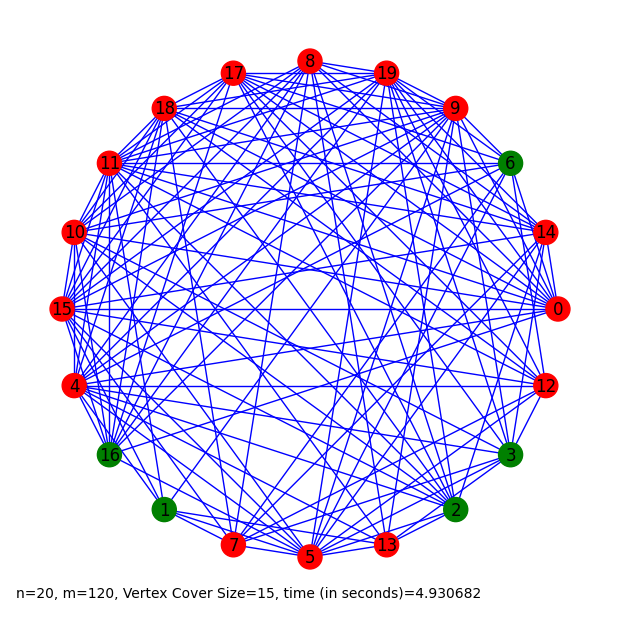

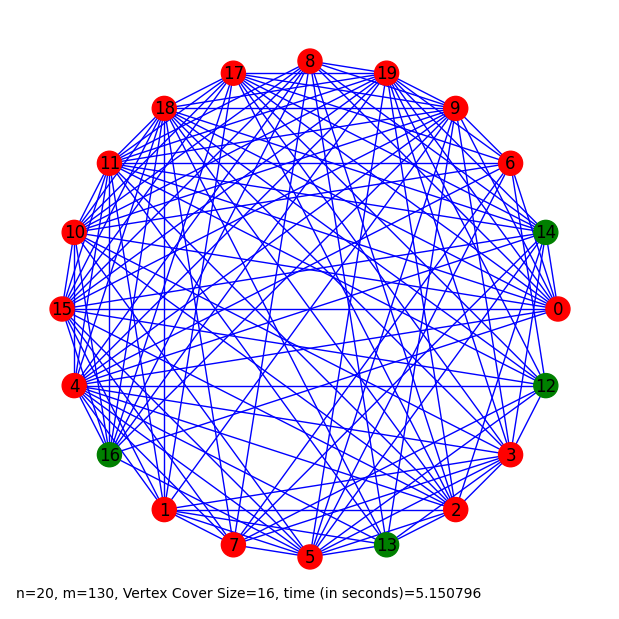

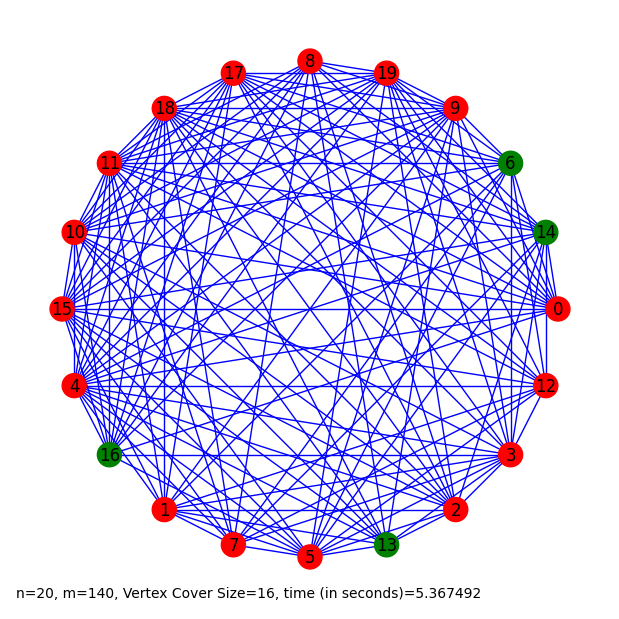

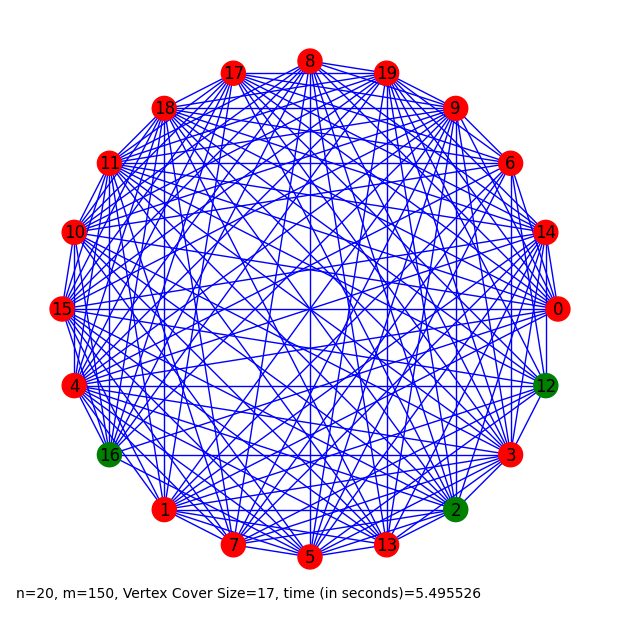

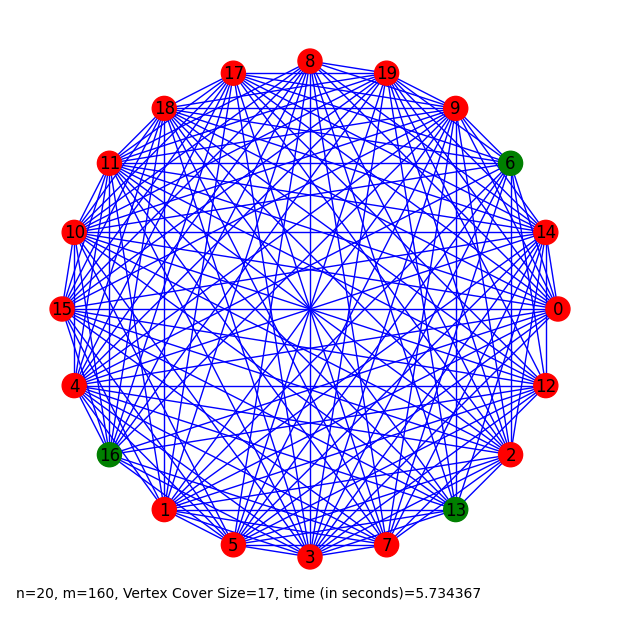

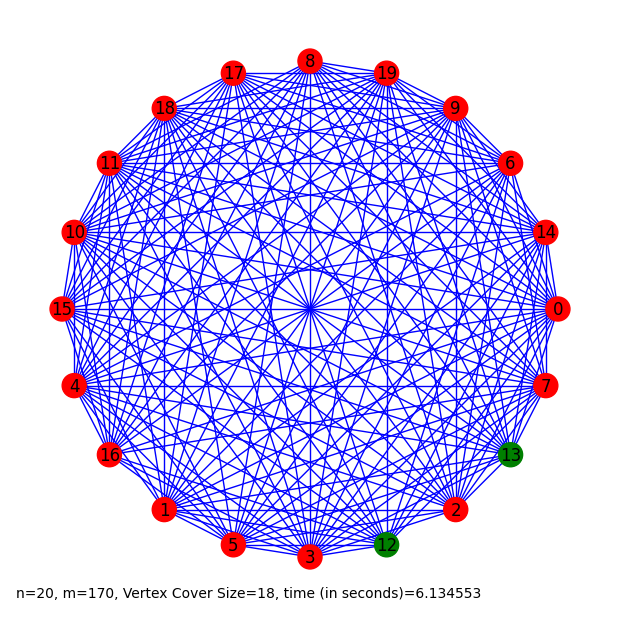

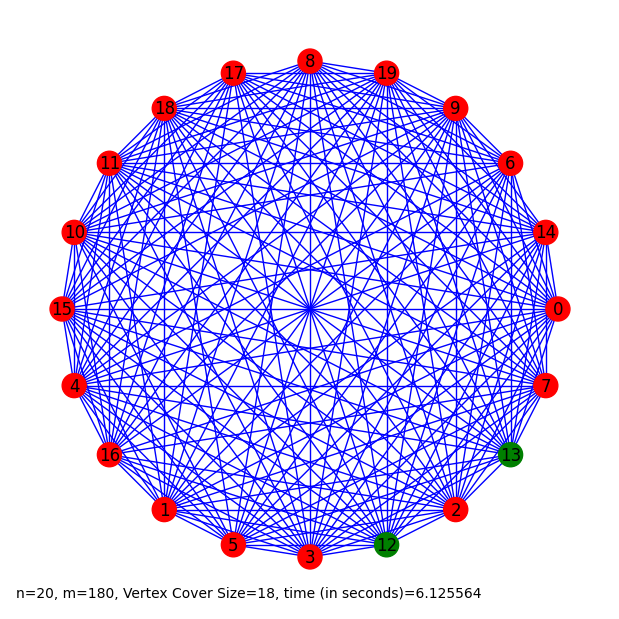

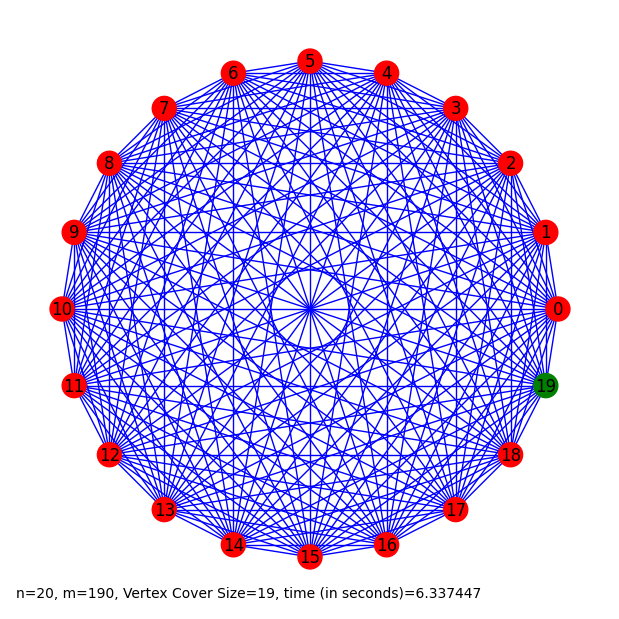

In [7]:
# Run brute force vertex cover method (method=0)
results_B_F = generate_vertex_covers(0)

# Convert results (list of dicts) into a DataFrame
df_opt = pd.DataFrame(results_B_F)

# Save the DataFrame as a CSV file
file_path = 'vertex_cover_brute_force_results.csv'
df_opt.to_csv(file_path, index=False)


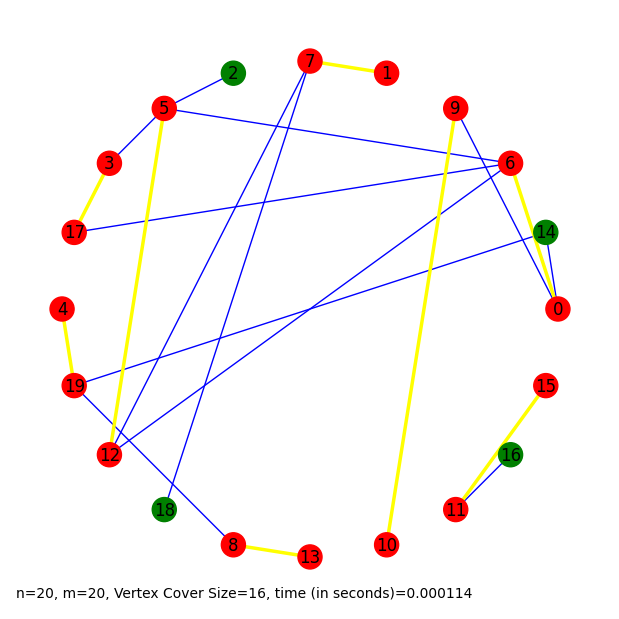

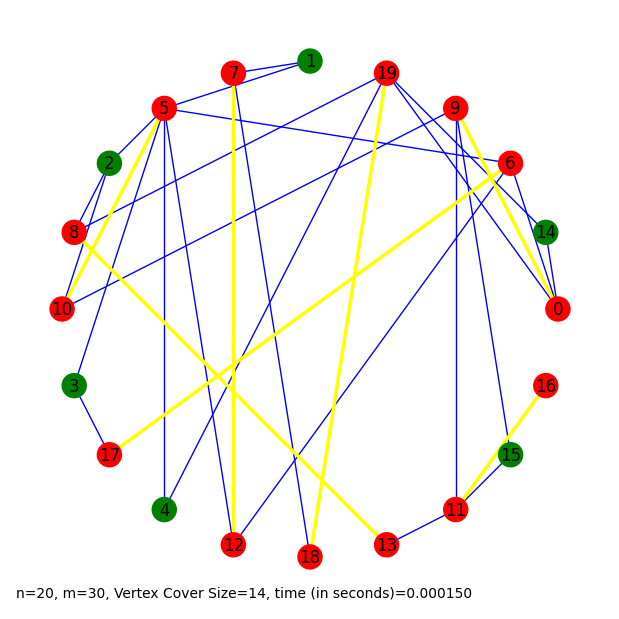

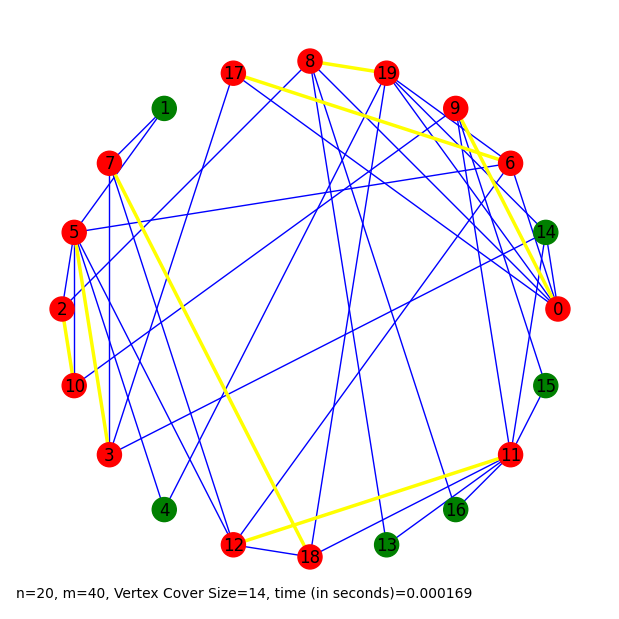

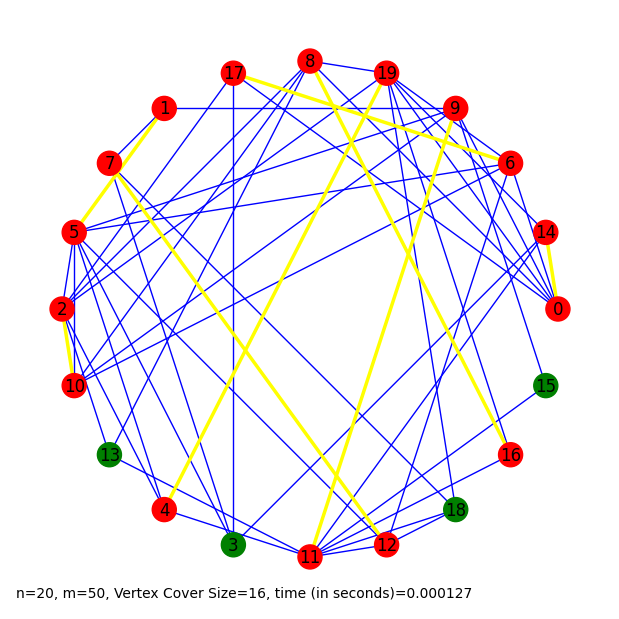

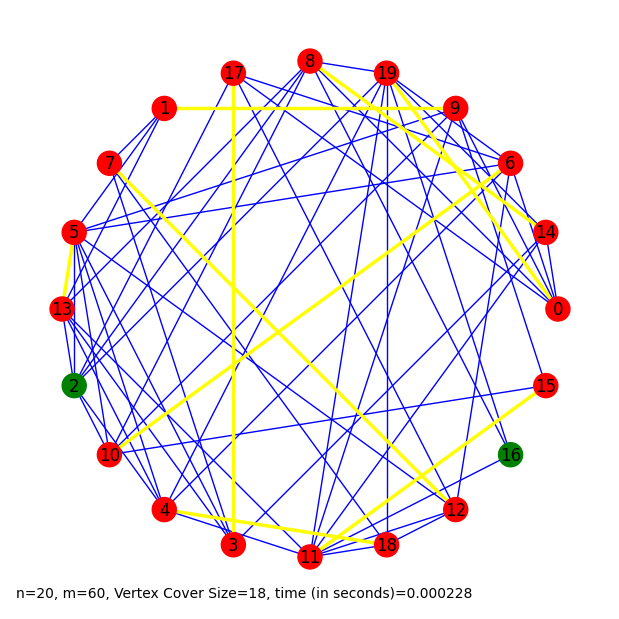

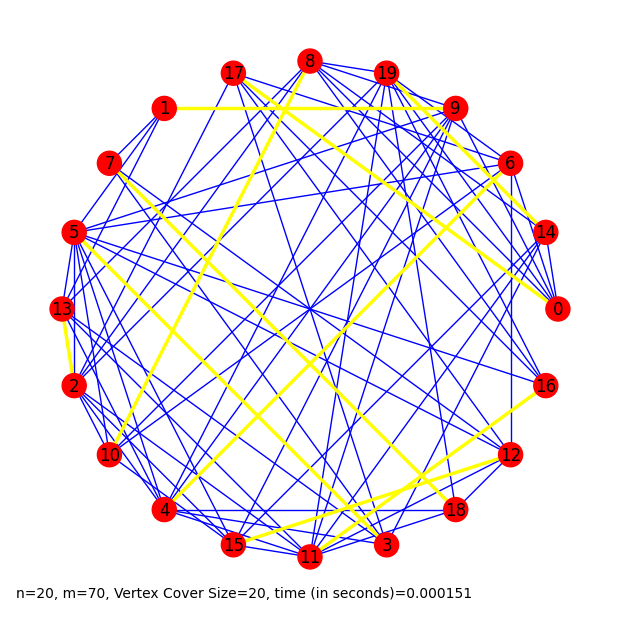

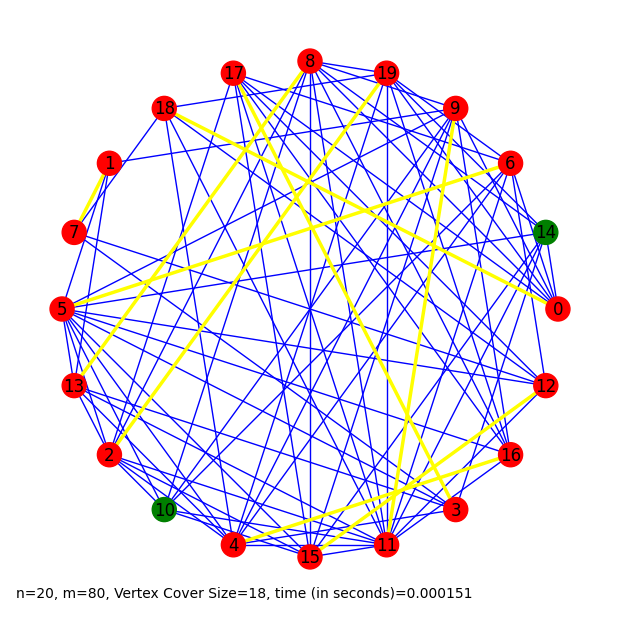

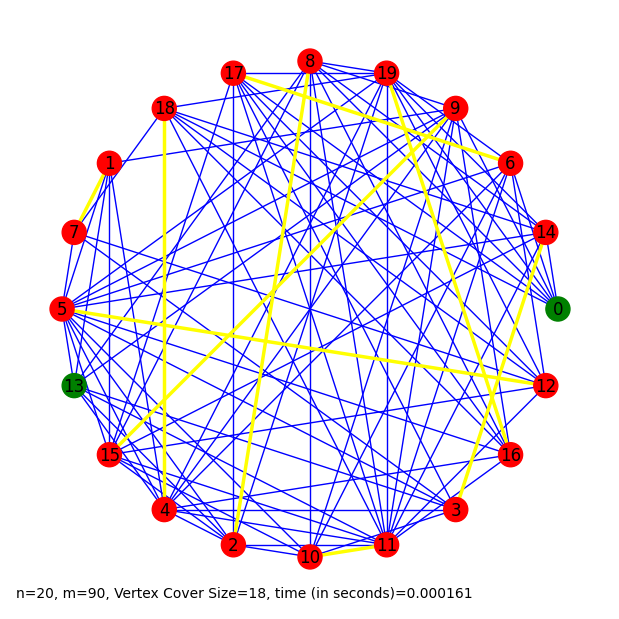

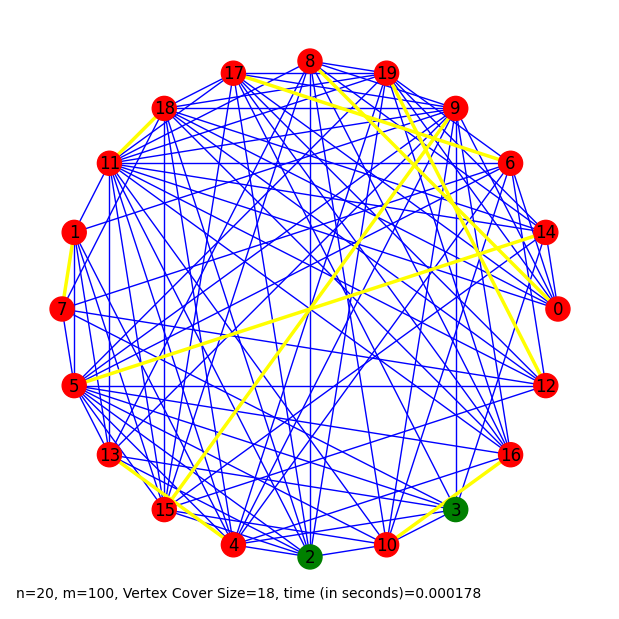

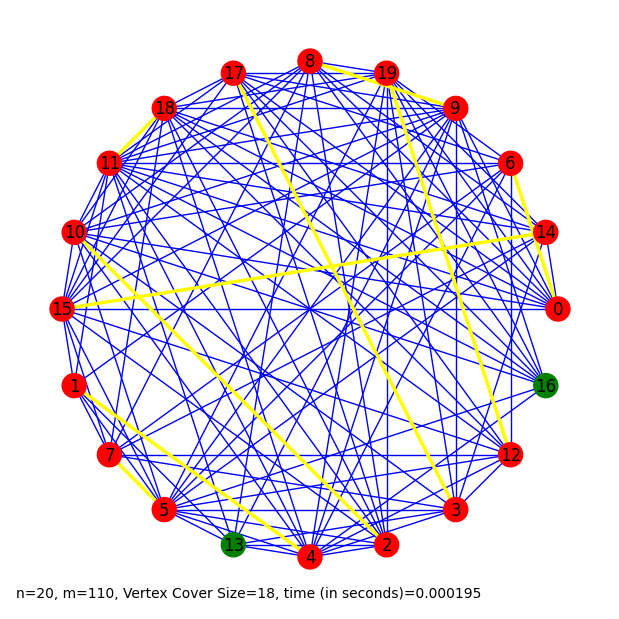

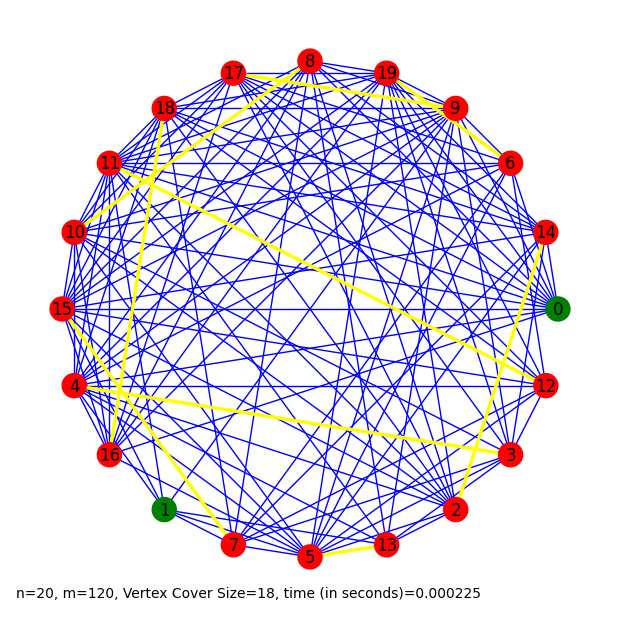

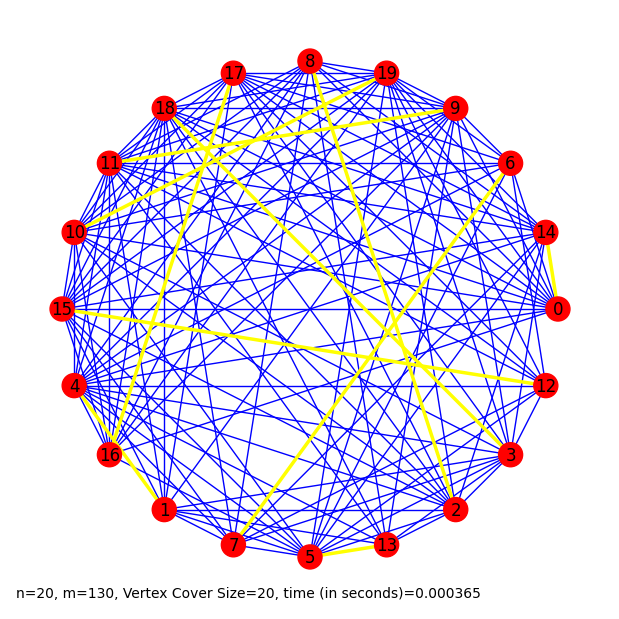

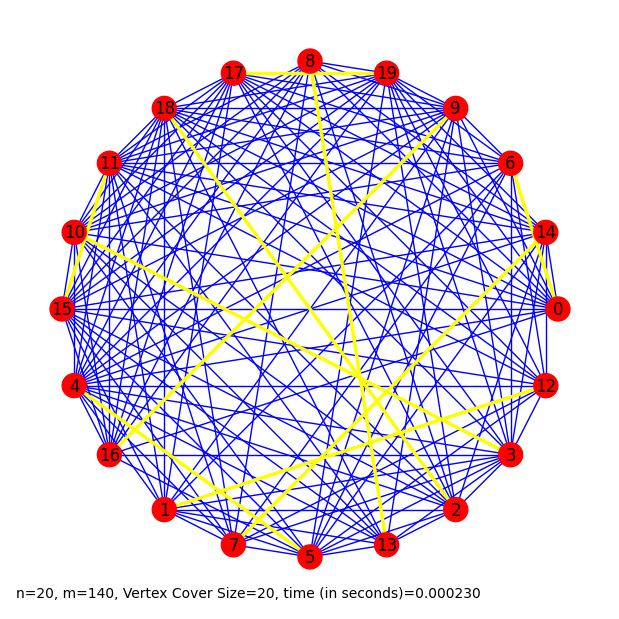

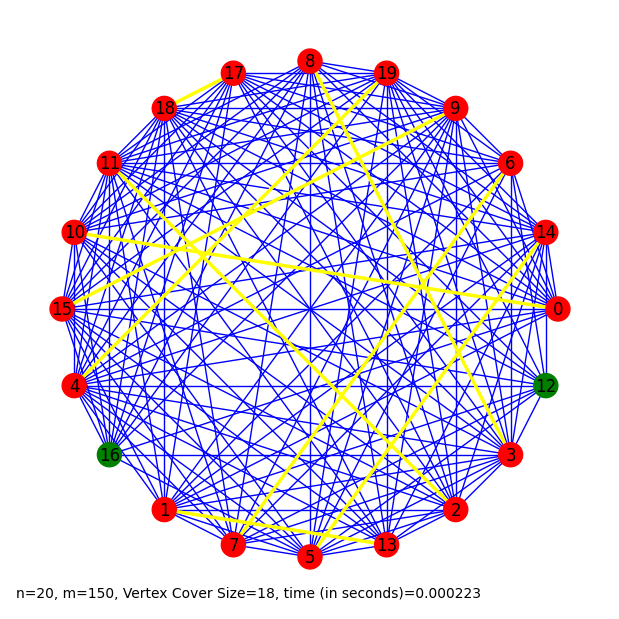

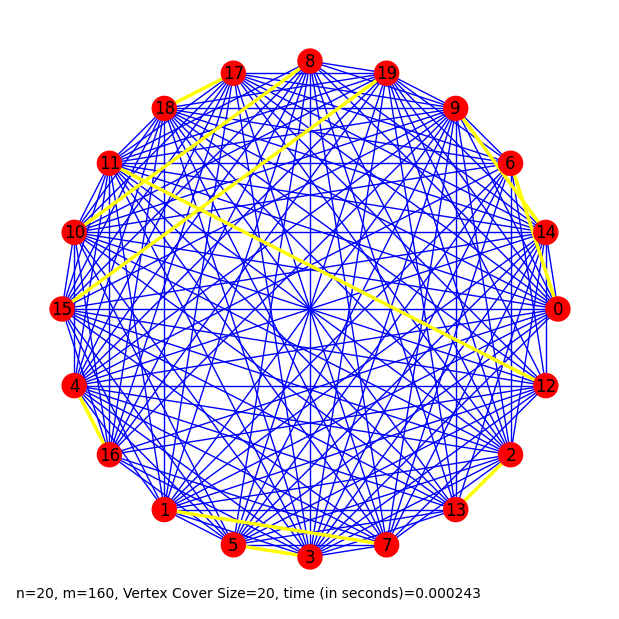

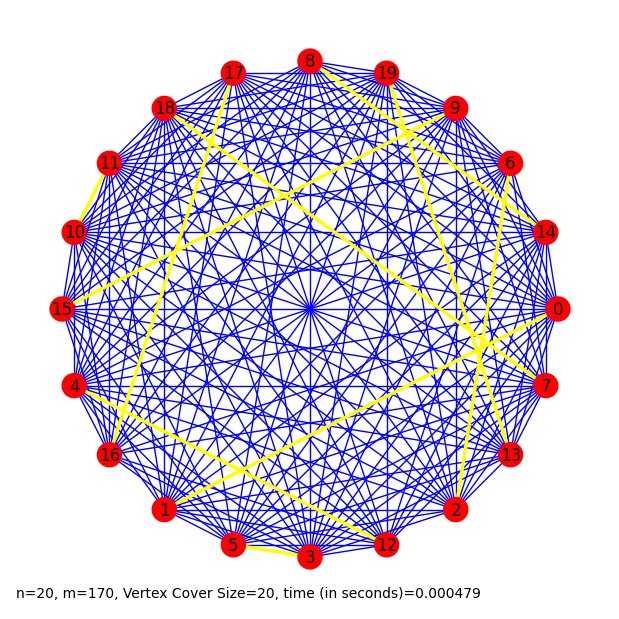

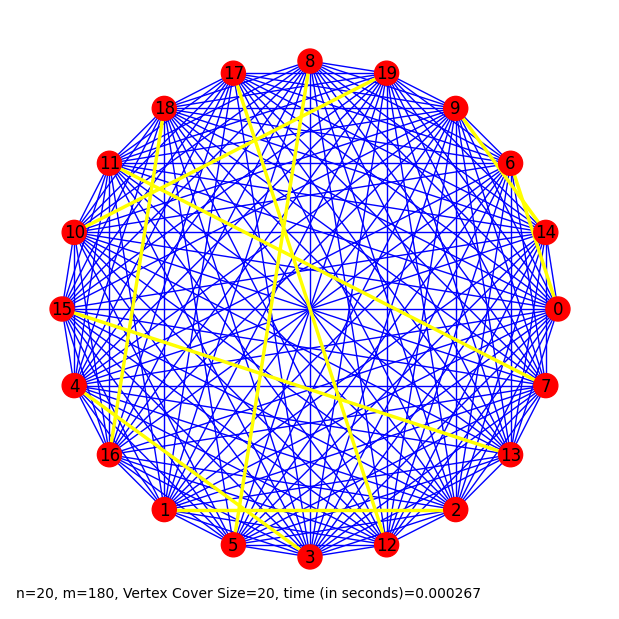

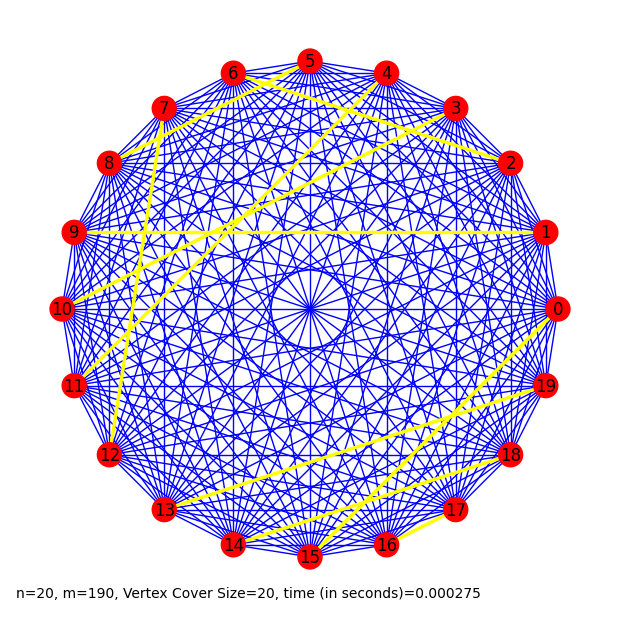

In [8]:
# Run 2 factor approximation vertex cover method (method=1)
results_2_Approx = generate_vertex_covers(1)

In [9]:
# Create a new DataFrame to store and compare the approximation factor and time taken to find vertex cover
df = pd.DataFrame(results_2_Approx)

# Rename column to distinguish greedy/approximation results
df = df.rename(columns={"vertex_cover_size": "greedy_vertex_cover_size"})

# Add the optimal (brute force) vertex cover sizes and times for comparison
df['opt_vertex_cover_size'] = df_opt['vertex_cover_size']
df['opt_vertex_cover_time (in seconds)'] = df_opt['time_(in seconds)']

# Compute approximation factor = (size of greedy cover / optimal cover size)
df['approximation_factor'] = df['greedy_vertex_cover_size'] / df['opt_vertex_cover_size']

# Save results to CSV file
file_path = 'vertex_cover_results_comparision.csv'
df.to_csv(file_path, index=False)

# Display the DataFrame
df


,n,m,greedy_vertex_cover_size,time_(in seconds),opt_vertex_cover_size,opt_vertex_cover_time (in seconds),approximation_factor
0,20,20,16,0.000114,9,0.802696,1.777778
1,20,30,14,0.000150,10,1.330808,1.400000
2,20,40,14,0.000169,11,2.029729,1.272727
3,20,50,16,0.000127,11,2.054311,1.454545
4,20,60,18,0.000228,13,3.220865,1.384615
5,20,70,20,0.000151,14,3.915733,1.428571
6,20,80,18,0.000151,14,4.009055,1.285714
7,20,90,18,0.000161,14,4.184417,1.285714
8,20,100,18,0.000178,14,4.275554,1.285714
9,20,110,18,0.000195,15,4.637251,1.200000


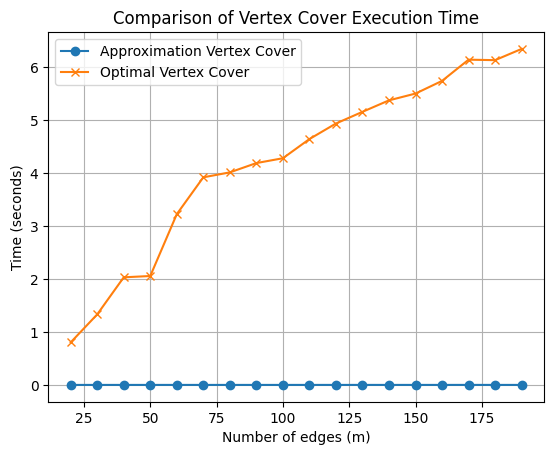

In [10]:
# Plot execution time of approximation vs optimal vertex cover algorithms
plt.plot(
    df['m'], 
    df['time_(in seconds)'], 
    marker='o', 
    label='Approximation Vertex Cover'
)

plt.plot(
    df['m'], 
    df['opt_vertex_cover_time (in seconds)'], 
    marker='x', 
    label='Optimal Vertex Cover'
)

# Label axes
plt.xlabel("Number of edges (m)")         # x-axis: number of edges in the graph
plt.ylabel("Time (seconds)")              # y-axis: execution time in seconds
plt.title("Comparison of Vertex Cover Execution Time")
plt.grid(True)
plt.legend()
plt.show()